/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/bmad/variables.py:78: UserWarning: Element BEGINNING not found in device mapping
  warnings.warn(f"Element {element_name} not found in device mapping")
/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/utils/variables.py:151: UserWarning: No variable configuration found for element type 'Instrument'
  warnings.warn(
/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/utils/variables.py:151: UserWarning: No variable configuration found for element type 'Multipole'
  warnings.warn(
/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/utils/variables.py:151: UserWarning: No variable configuration found for element type 'Monitor'
  warnings.warn(
/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/bmad/variables.py:78: UserWarning: Element L0A not found in device mapping
  warnings.war

Setting QUAD:IN20:525:BCTRL to -10.0
Setting QUAD:IN20:525:BCTRL to -5.0
Setting QUAD:IN20:525:BCTRL to 0.0
Setting QUAD:IN20:525:BCTRL to 5.0
Setting QUAD:IN20:525:BCTRL to 10.0


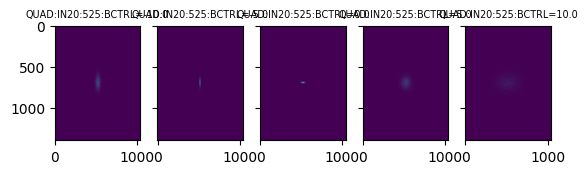

In [5]:
from virtual_accelerator.models.staged_model import get_cu_hxr_staged_model
model = get_cu_hxr_staged_model()

# do a quadrupole scan using QUAD:IN20:525:BCTRL and plot the beam distribution at OTR3
import matplotlib.pyplot as plt
import numpy as np

OTR_IMAGE_PV = "OTRS:IN20:711:Image:ArrayData"
SCAN_QUAD_PV = "QUAD:IN20:525:BCTRL"

quad_values = np.linspace(-10, 10, 5)
fig, ax = plt.subplots(
    1, 
    len(quad_values), 
    sharex=True, 
    sharey=True
)
rms_sizes = []
for i, quad_value in enumerate(quad_values):
    print(f"Setting {SCAN_QUAD_PV} to {quad_value:.1f}")
    model.set({SCAN_QUAD_PV: quad_value})
    image = model.get([OTR_IMAGE_PV])[OTR_IMAGE_PV]
    ax[i].imshow(-image,rasterized=True)
    ax[i].set_title(f"{SCAN_QUAD_PV}={quad_value:.1f}", fontsize="x-small")

#fig.savefig("cu_hxr_staged_model_quad_scan.png")


In [6]:
fig.savefig("cu_hxr_staged_model_quad_scan.svg")